In [1]:
%%capture
import warnings
warnings.filterwarnings('ignore')

import os
os.environ["CALITP_BQ_MAX_BYTES"] = str(800_000_000_000)
import shared_utils
import utils

from calitp.tables import tbl
from calitp import query_sql
import calitp.magics

from siuba import *
import pandas as pd
import geopandas as gpd

import datetime as dt

import importlib
import rt_filter_map_plot

from IPython.display import display, Markdown, Latex, HTML
import json

### Quick proof of concept and utils for querying all trips

In [3]:
import gcsfs
fs = gcsfs.GCSFileSystem()

In [4]:
fs_list = fs.ls(f'{utils.GCS_FILE_PATH}rt_trips/')

In [8]:
analysis_date = dt.date(2022, 6, 1) ##wednesday, new tables

In [13]:
analysis_date.strftime('%m_%d')

'06_01'

In [21]:
def paths_on_date(fs_list, analysis_date):
    path_date = analysis_date.strftime('%m_%d')
    return [path.split('/rt_delay/')[1] for path in fs_list if path.split('.')[0][-5:] == path_date]

In [22]:
june_1_paths = paths_on_date(fs_list, analysis_date)

In [20]:
utils.GCS_FILE_PATH

'gs://calitp-analytics-data/data-analyses/rt_delay/'

In [27]:
def read_concat_all(subpaths, gcs_path = utils.GCS_FILE_PATH):
    output = pd.DataFrame()
    for subpath in subpaths:
        output = pd.concat([output, pd.read_parquet(f'{gcs_path}{subpath}')])
    return output

In [28]:
ca_trips = read_concat_all(june_1_paths)

In [31]:
ca_trips = ca_trips >> filter(_.route_type == '3')

In [29]:
ca_trips >> head(3)

,calitp_itp_id,calitp_url_number,service_date,trip_key,trip_id,route_id,direction_id,shape_id,calitp_extracted_at,calitp_deleted_at,route_short_name,route_long_name,route_desc,route_type,median_time,direction,mean_speed_mph,calitp_agency_name
0,110,0,2022-06-01,7695271526234679582,t_2088727_b_34014_tn_2,978,0,p_1306150,2022-03-18,2099-01-01,6,Solano Town Ctr/Suisun Senior Ctr/Lawler Ranch,None,3,09:16:05,Westbound,8.627295,Fairfield and Suisun Transit
1,110,0,2022-06-01,-6483963454995657246,t_2088727_b_34014_tn_4,978,0,p_1306150,2022-03-18,2099-01-01,6,Solano Town Ctr/Suisun Senior Ctr/Lawler Ranch,None,3,11:21:45,Westbound,9.773278,Fairfield and Suisun Transit
2,110,0,2022-06-01,-5095643932337353181,t_2088729_b_34014_tn_0,978,0,p_2488,2022-03-18,2099-01-01,6,Solano Town Ctr/Suisun Senior Ctr/Lawler Ranch,None,3,16:47:16.500000,Westbound,15.242512,Fairfield and Suisun Transit


In [33]:
ca_trips.mean_speed_mph.median()

10.860053710863333

In [34]:
lbt_june_1 = rt_day = rt_filter_map_plot.from_gcs(170, analysis_date)

In [44]:
lbt_june_1.set_filter(start_time='15:00', end_time='19:00', route_names=['175'], shape_ids=['1750014'])

In [45]:
lbt_june_1.segment_speed_map(how='low_speeds')

Text(0.5, 1.0, 'Long Beach Transit Speed Variability by Stop Segment, Route(s) 175, Westbound, PM Peak, Jun 01 (Wed)')

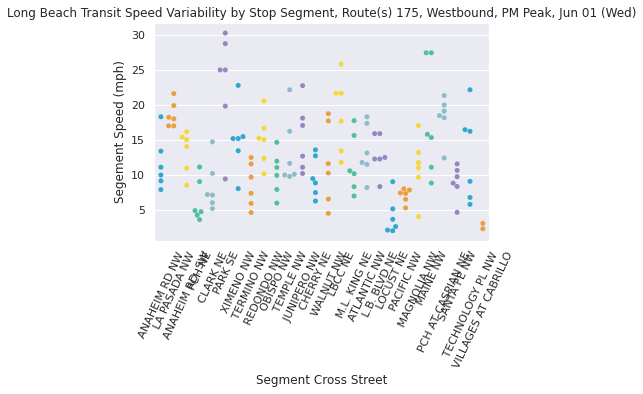

In [46]:
lbt_june_1.chart_variability()

In [48]:
sf_pre_van_ness = rt_filter_map_plot.from_gcs(282, dt.date(2022, 3, 30))

In [65]:
sf_post_van_ness = rt_filter_map_plot.from_gcs(282, dt.date(2022, 5, 18))

In [103]:
sf_pre_van_ness.set_filter(start_time='15:00', end_time='19:00', route_names=['49'], shape_ids=['195396'])

In [95]:
sf_pre_van_ness._filter(sf_pre_van_ness.rt_trips).shape_id.unique()

array(['195396', '195397', '195398', '195399'], dtype=object)

In [98]:
sf_pre_van_ness._filter(sf_pre_van_ness.rt_trips) >> count(_.shape_id)

,shape_id,n
0,195396,14
1,195397,14
2,195398,14
3,195399,15


In [102]:
sf_pre_van_ness.segment_speed_map(how='low_speeds')

In [104]:
sf_post_van_ness.set_filter(start_time='15:00', end_time='19:00', route_names=['49'], shape_ids=['202443'])

In [100]:
sf_post_van_ness._filter(sf_post_van_ness.rt_trips) >> count(_.shape_id)

,shape_id,n
0,202442,16
1,202443,20
2,202444,13
3,202445,20


In [105]:
sf_post_van_ness.segment_speed_map(how='low_speeds')

In [85]:
sf_post_van_ness.stop_segment_speed_view = sf_post_van_ness.stop_segment_speed_view >> filter(_.speed_mph < 30)

In [92]:
sf_pre_van_ness._filter(sf_pre_van_ness.rt_trips).mean_speed_mph.median()

7.514219622332803

In [93]:
sf_post_van_ness._filter(sf_post_van_ness.rt_trips).mean_speed_mph.median()

7.504447876305706

Text(0.5, 1.0, 'MUNI Speed Variability by Stop Segment, Route(s) 49, Southbound, PM Peak, Mar 30 (Wed)')

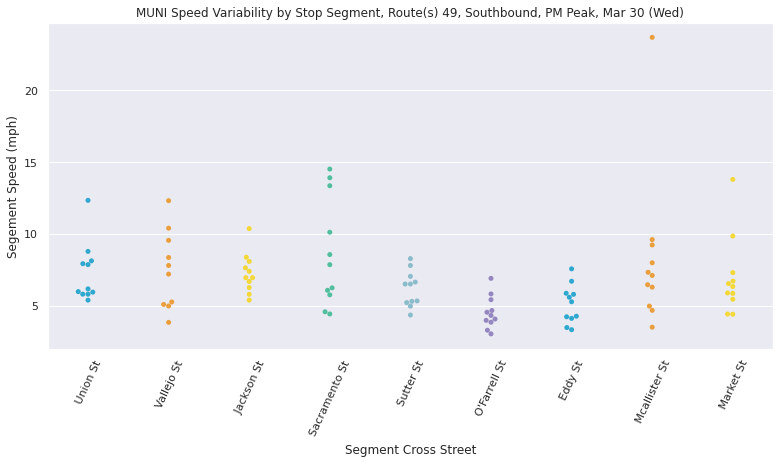

In [109]:
sf_pre_van_ness.chart_variability(max_stop_seq=17)

Text(0.5, 1.0, 'MUNI Speed Variability by Stop Segment, Route(s) 49, Southbound, PM Peak, May 18 (Wed)')

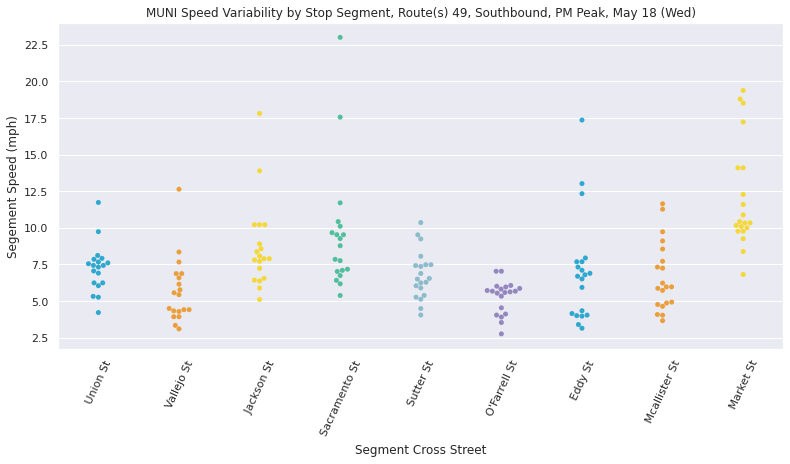

In [113]:
sf_post_van_ness.chart_variability(min_stop_seq=9, max_stop_seq=17)

In [115]:
post = sf_post_van_ness._filter(sf_post_van_ness.stop_segment_speed_view) >> filter(_.stop_sequence < 18, _.stop_sequence > 8)

In [116]:
pre = sf_pre_van_ness._filter(sf_pre_van_ness.stop_segment_speed_view) >> filter(_.stop_sequence < 18)

In [125]:
post.speed_mph.quantile(.2)

5.2664719466136205

In [126]:
pre.speed_mph.quantile(.2)

4.663752499222573

In [127]:
(5.266 - 4.66) / 4.66

0.1300429184549356